In [1]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.crs import CRS
from pathlib import Path

import sys
sys.path.append("../loaders/")
import DataStack as ds

In [2]:
# CONFIG

TARGET_CRS    = CRS.from_epsg(32638)
TARGET_RES    = 3 # 1m
TILE_SIZE     = 512
OVERLAP       = 0.15
OUT_PATH      = '../../data/tiles_out/Russia/Area1/'
SPECTRAL_PATH = Path('../../data/Russia/Area1/data/Planet/Russia_SCDs_Prep_psscene_analytic_sr_udm2/composite.tif')
DEM_PATH = Path('../../data/Russia/Area1/data/DEM/merged_DEM_N51_E041_E042.tif')
OUTPUT_PATH = Path('../../data/Russia/Area1/data/labels_as_tiff.tif')


In [3]:
with rio.open(SPECTRAL_PATH) as src:
    BOUNDS = src.bounds

In [4]:
print(BOUNDS)

BoundingBox(left=267243.30140968546, bottom=5657116.702046329, right=301221.30140968546, top=5678839.702046329)


In [5]:
band_map = {'B': 1, 'G': 2, 'R': 3, 'NIR': 4}

sources = {
    name: ds.DataSource.from_tiff(
        SPECTRAL_PATH,
        type=name,
        band_idx=idx,
    )
    for name, idx in band_map.items()
}

sources['DEM'] = ds.DataSource.from_tiff(
    DEM_PATH,
    type='DEM'
)


In [8]:
stack = ds.DataStack(sources, TARGET_CRS, TARGET_RES, BOUNDS, labelled=False, features=['R', 'G', 'B','DEM', 'TPI_75'])

308 tiles available


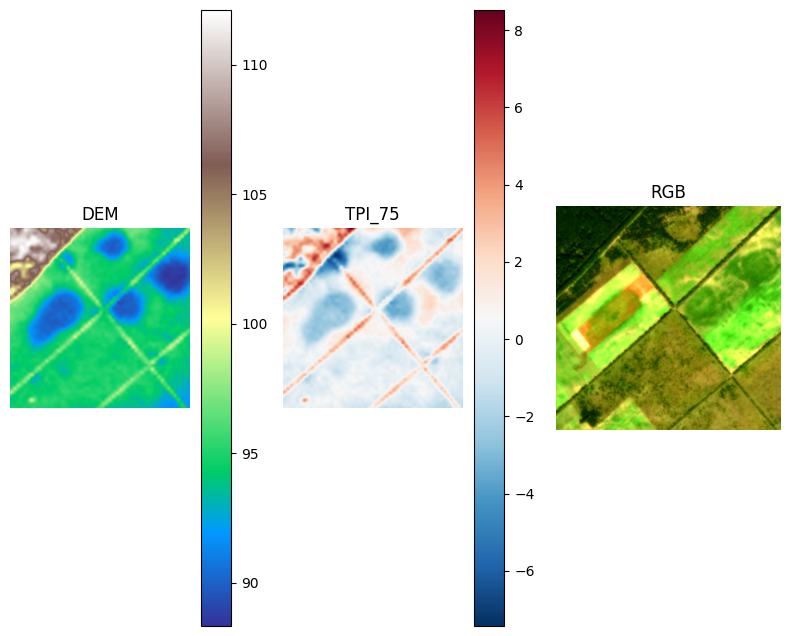

In [9]:
stack.view_tile(index=200)